# **SEARCH SERVICE**

In [19]:
from IPython.display import Image, display

from diagrams import Diagram, Edge
from diagrams.c4 import Container, Database, System, SystemBoundary

## **OVERVIEW**

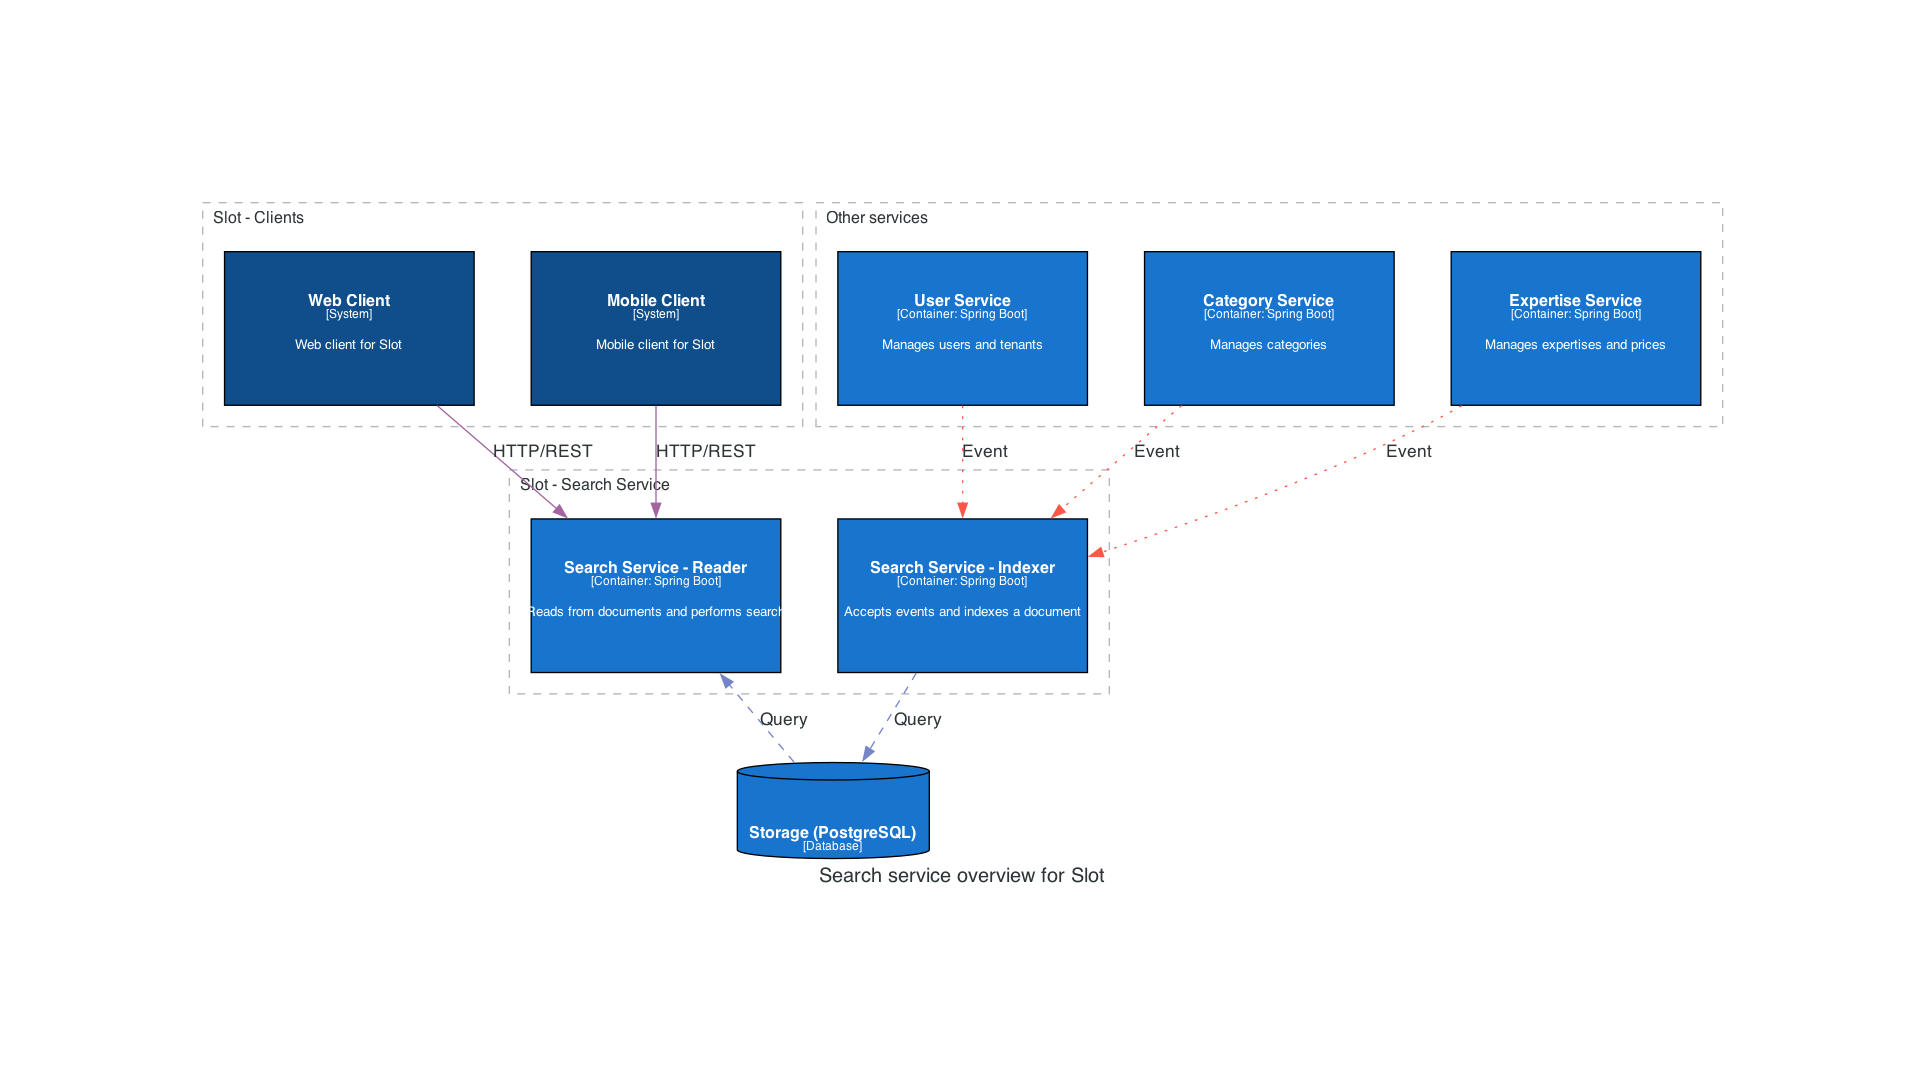

In [20]:
http  = Edge(label="HTTP/REST", color="#a265a1")
event = Edge(label="Event", color="#fd5847", style="dotted")
query = Edge(label="Query", color="#7684c8", style="dashed")

graph_attr = {
    "splines": "spline",
}

with Diagram("Search service overview for Slot", direction="TB", graph_attr=graph_attr, show=False):
    with SystemBoundary("Slot - Clients"):
        client_web    = System(name="Web Client",    description="Web client for Slot")
        client_mobile = System(name="Mobile Client", description="Mobile client for Slot")

    with SystemBoundary("Other services"):
            user_service = Container(
                name="User Service",
                technology="Spring Boot",
                description="Manages users and tenants",
            )
            category_service = Container(
                name="Category Service",
                technology="Spring Boot",
                description="Manages categories",
            )
            expertise_service = Container(
                name="Expertise Service",
                technology="Spring Boot",
                description="Manages expertises and prices",
            )

    with SystemBoundary("Slot - Search Service"):
            search_service_indexer = Container(
                name="Search Service - Indexer",
                technology="Spring Boot",
                description="Accepts events and indexes a document",
            )
            search_service_reader = Container(
                name="Search Service - Reader",
                technology="Spring Boot",
                description="Reads from documents and performs search",
            )

    db = Database("Storage (PostgreSQL)")

    [user_service, category_service, expertise_service] >> event >> search_service_indexer
    [client_web, client_mobile] >> http >> search_service_reader
    search_service_indexer >> query >> db
    db >> query >> search_service_reader

display(Image("search_service_overview_for_slot.png"))